<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml15_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PCA(Principal Component Analysis, 주성분 분석)

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 데이터셋

In [2]:
!wget https://bit.ly/fruits_300_data -O fruits.npy

--2026-08-13 06:03:49--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-08-13 06:03:49--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-08-13 06:03:49--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... conne

In [3]:
fruits = np.load('fruits.npy')

In [4]:
fruits.shape  # 100x100 픽셀 크기의 흑백 이미지 300개

(300, 100, 100)

In [11]:
def plot_img_array(arr, ncols=10):
    # arr: (n_samples, height, width) 모양의 3차원 배열
    # ncols: 서브 플롯의 열 개수
    n = len(arr)
    nrows = int(np.ceil(n / ncols))  # 서브 플롯의 행 개수
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols, nrows))
    for i in range(nrows):
        for j in range(ncols):
            idx = i * ncols + j
            if nrows == 1 or ncols == 1:  # axes가 1차원 배열인 경우
                if idx < n:  # 실제 샘플 개수만큼만 시각화
                    axes[idx].imshow(arr[idx], cmap=plt.cm.binary)
                axes[idx].axis('off')
            else:  # axes가 2차원 배열인 경우
                if idx < n:
                    axes[i, j].imshow(arr[idx], cmap=plt.cm.binary)
                axes[i, j].axis('off')

    plt.show()

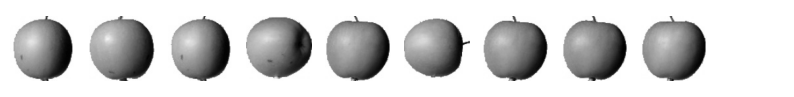

In [13]:
plot_img_array(fruits[:9])

# PCA

*   데이터에서 분산이 최대가 되는 축(주성분, principal component)을 찾음.
*   첫번째 축에 수직(직교, orthogonal)이면서 남은 분산이 최대가 되는 두번째 축을 찾음.
*   이전에 찾은 모든 축에 수직이면 남은 분산이 최대가 되는 새로운 축을 찾음.
*   위의 과정을 반복.
*   주성분 분석을 사용해서 차원을 축소할 수 있음. 원래 차원으로 재구성할 수도 있음.
    *   재구성 오차가 발생함.